# Auto EDA Notebook
Upload your dataset and this notebook will automatically clean it and perform EDA with insights.

In [1]:
%pip install pandas numpy matplotlib seaborn missingno -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## Step 1 — Load Dataset
Change the file path below to your CSV file.

In [3]:
# ✏️ Change this to your file path
FILE_PATH = 'tested.csv'

df = pd.read_csv(FILE_PATH)
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 418 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Step 2 — Basic Info

In [4]:
print('--- Shape ---')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\n--- Column Types ---')
print(df.dtypes)

print('\n--- Basic Info ---')
df.info()

--- Shape ---
Rows: 418, Columns: 12

--- Column Types ---
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 n

## Step 3 — Data Cleaning

In [5]:
# --- Duplicates ---
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')
df = df.drop_duplicates()
print(f'After removing duplicates: {df.shape[0]} rows')

Duplicate rows: 0
After removing duplicates: 418 rows


In [6]:
# --- Missing Values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print('No missing values found!')
else:
    print('Columns with missing values:')
    print(missing_df)

Columns with missing values:
       Missing Count  Missing %
Cabin            327      78.23
Age               86      20.57
Fare               1       0.24


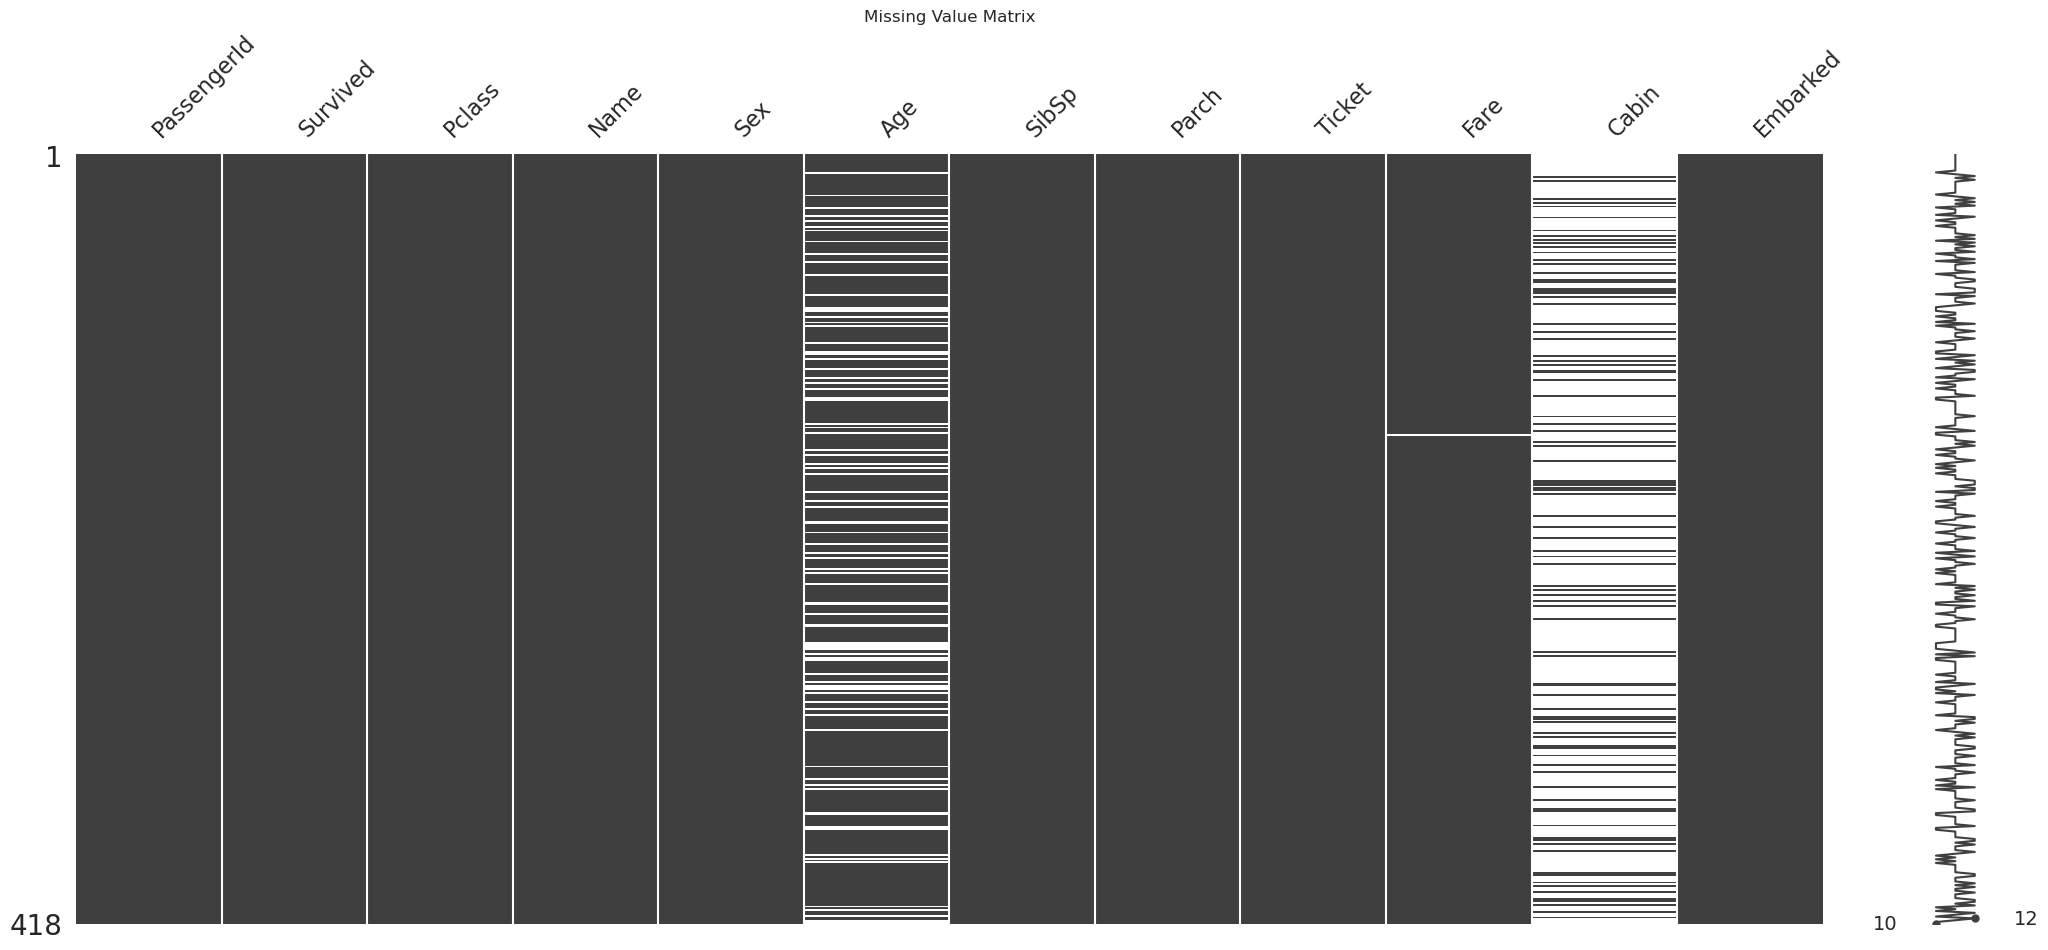

In [7]:
# --- Visualize Missing Values ---
if df.isnull().sum().sum() > 0:
    msno.matrix(df)
    plt.title('Missing Value Matrix')
    plt.show()
else:
    print('No missing values to visualize.')

In [8]:
# --- Handle Missing Values ---
# Numeric columns: fill with median
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'Filled {col} with median')

# Categorical columns: fill with mode
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'Filled {col} with mode')

print(f'\nMissing values after cleaning: {df.isnull().sum().sum()}')

Filled Age with median
Filled Fare with median
Filled Cabin with mode

Missing values after cleaning: 0


## Step 4 — Statistical Summary

In [9]:
print('--- Numeric Columns Summary ---')
df[num_cols].describe().round(3)

--- Numeric Columns Summary ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.00,418.000,418.000,418.000,418.000,418.000,418.000
mean,1100.50,0.364,2.266,29.599,0.447,0.392,35.577
std,120.81,0.482,0.842,12.704,0.897,0.981,55.850
min,892.00,0.000,1.000,0.170,0.000,0.000,0.000
25%,996.25,0.000,1.000,23.000,0.000,0.000,7.896
50%,1100.50,0.000,3.000,27.000,0.000,0.000,14.454
75%,1204.75,1.000,3.000,35.750,1.000,0.000,31.472
max,1309.00,1.000,3.000,76.000,8.000,9.000,512.329


In [10]:
if cat_cols:
    print('--- Categorical Columns Summary ---')
    df[cat_cols].describe()

--- Categorical Columns Summary ---


## Step 5 — Univariate Analysis

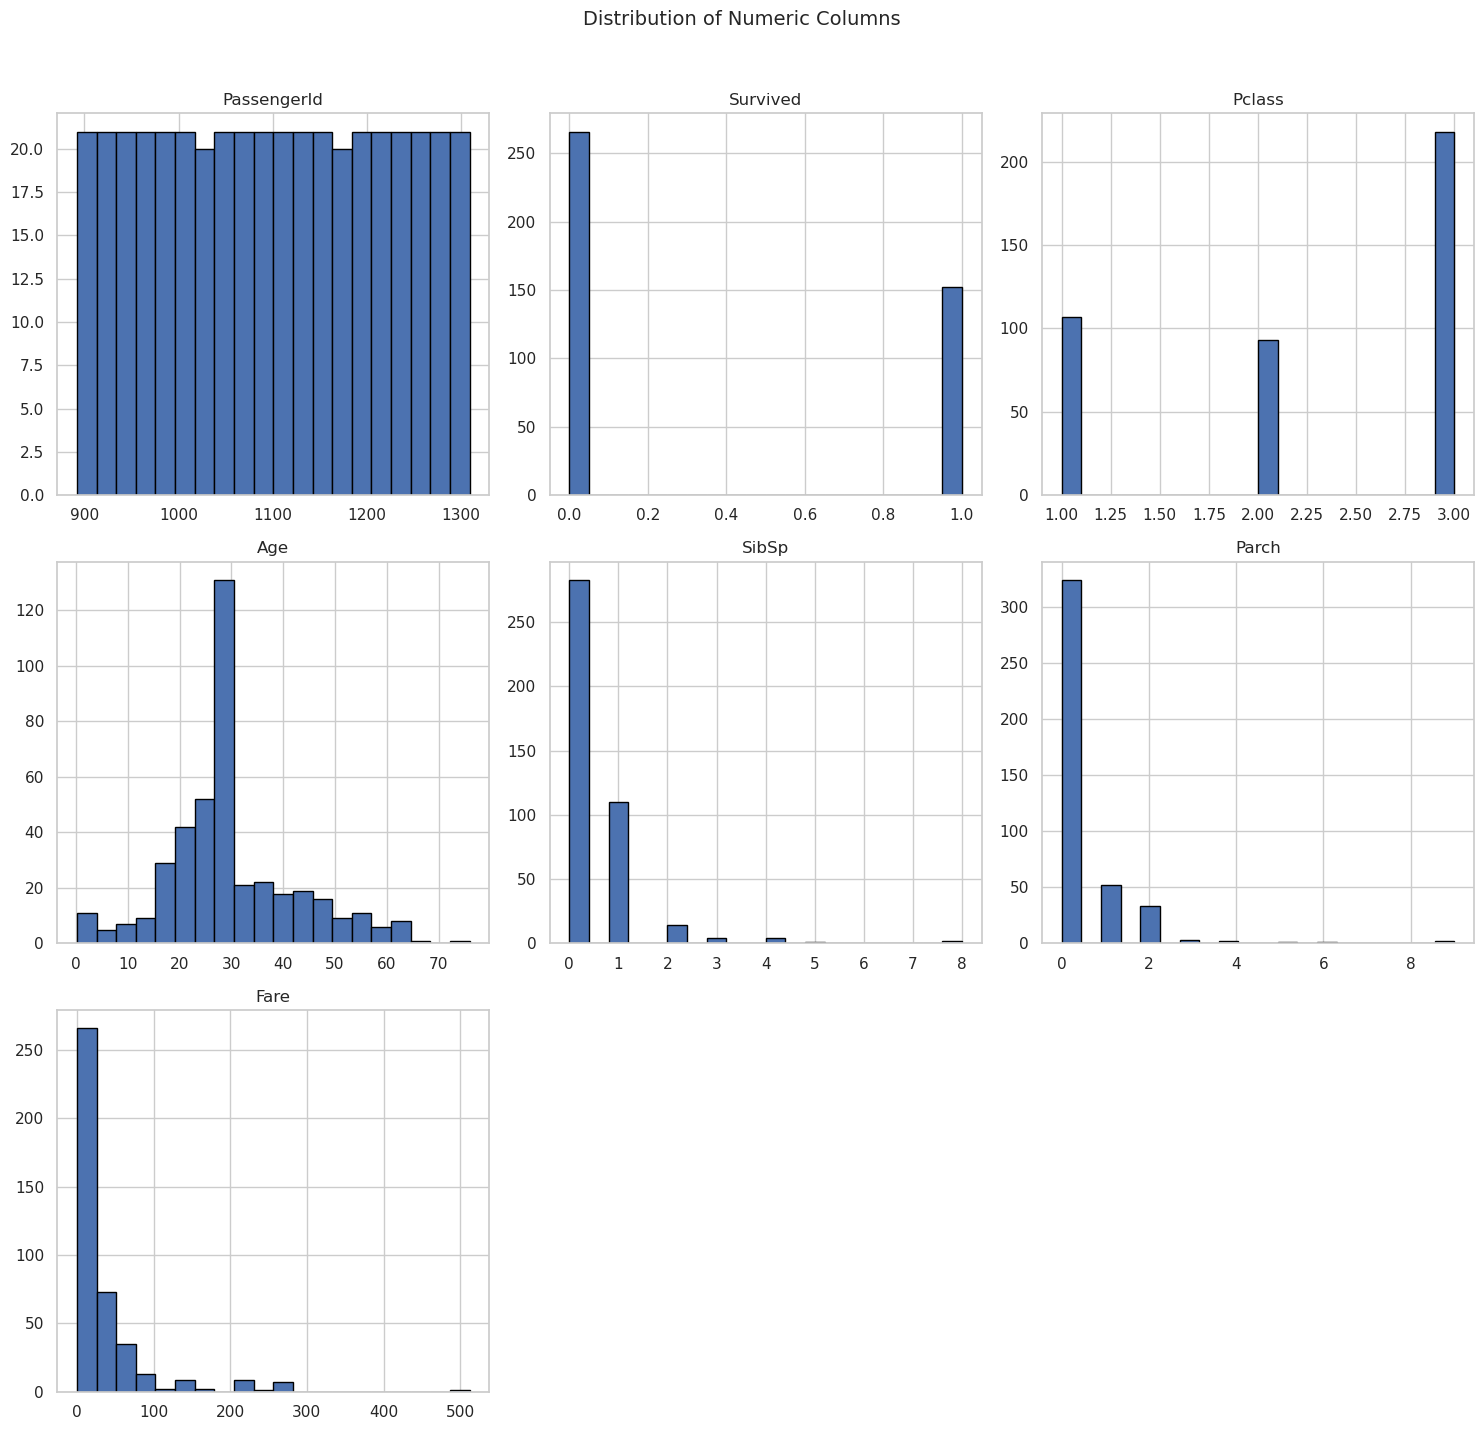

In [11]:
# Histograms for numeric columns
if num_cols:
    df[num_cols].hist(bins=20, figsize=(15, len(num_cols) * 2), layout=(-1, 3), edgecolor='black')
    plt.suptitle('Distribution of Numeric Columns', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

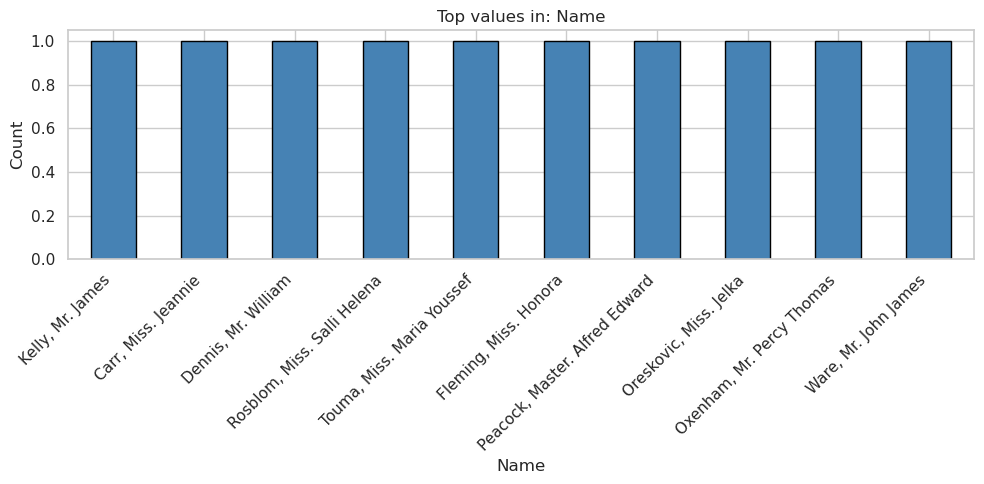

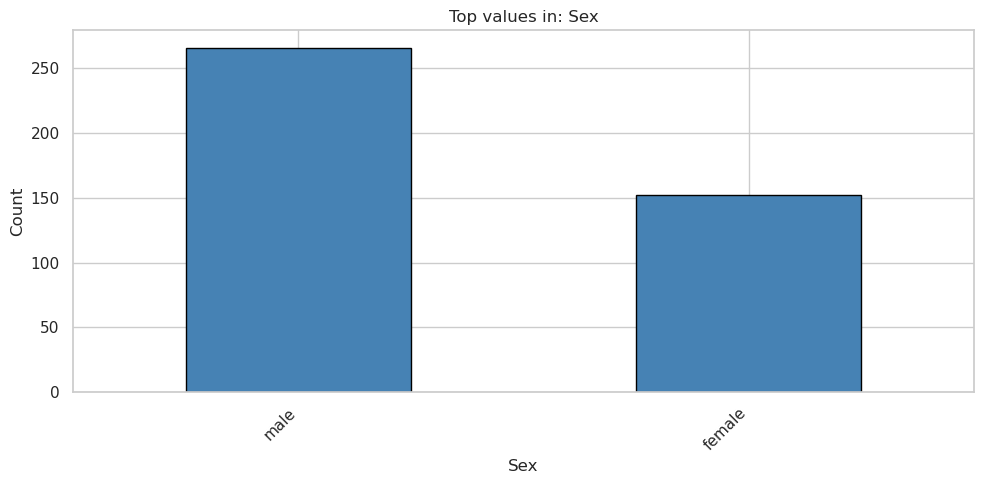

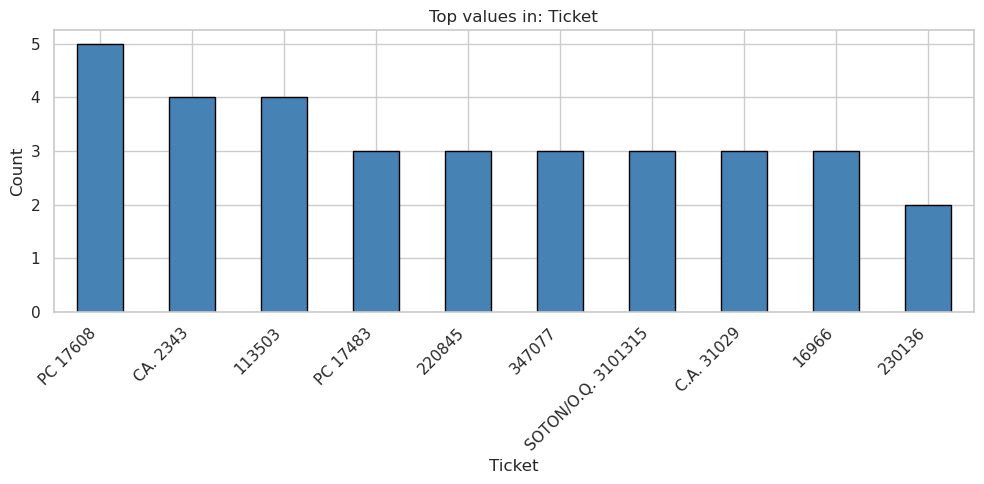

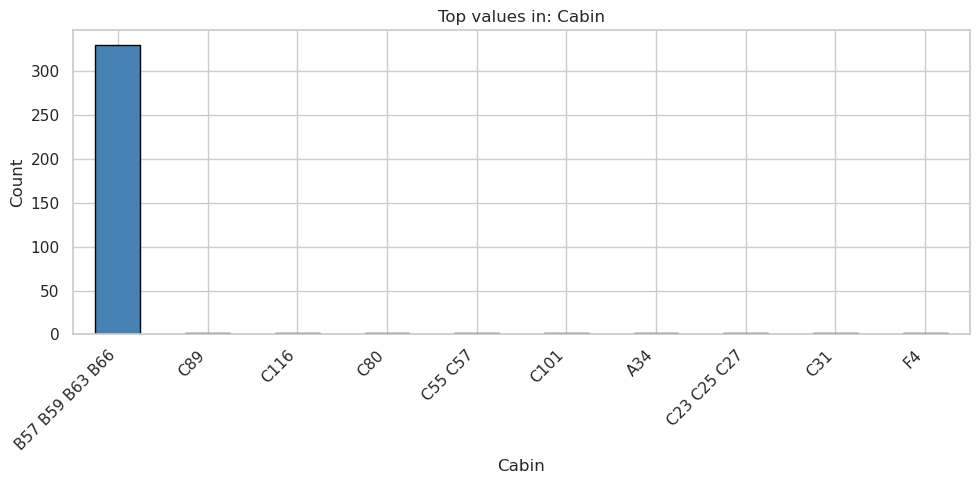

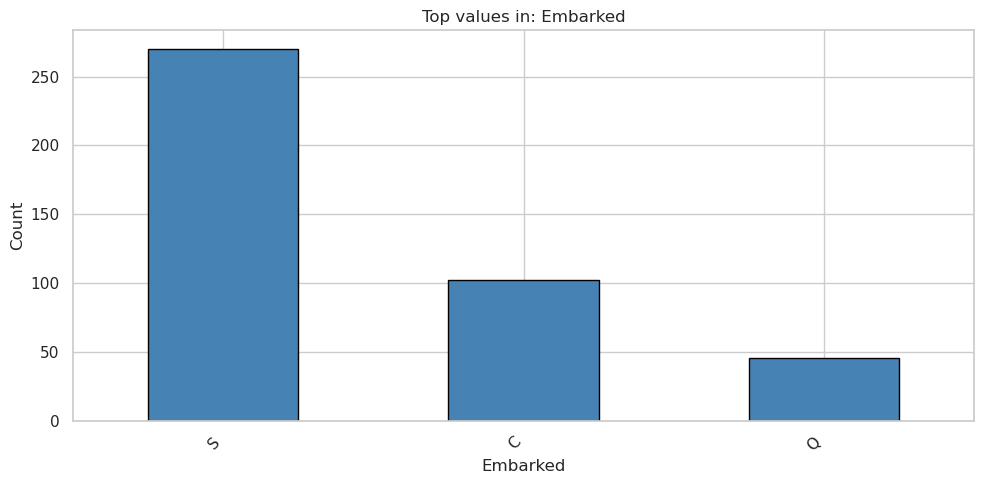

In [12]:
# Bar plots for categorical columns (top 10 values each)
for col in cat_cols:
    top = df[col].value_counts().head(10)
    top.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Top values in: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Step 6 — Outlier Detection

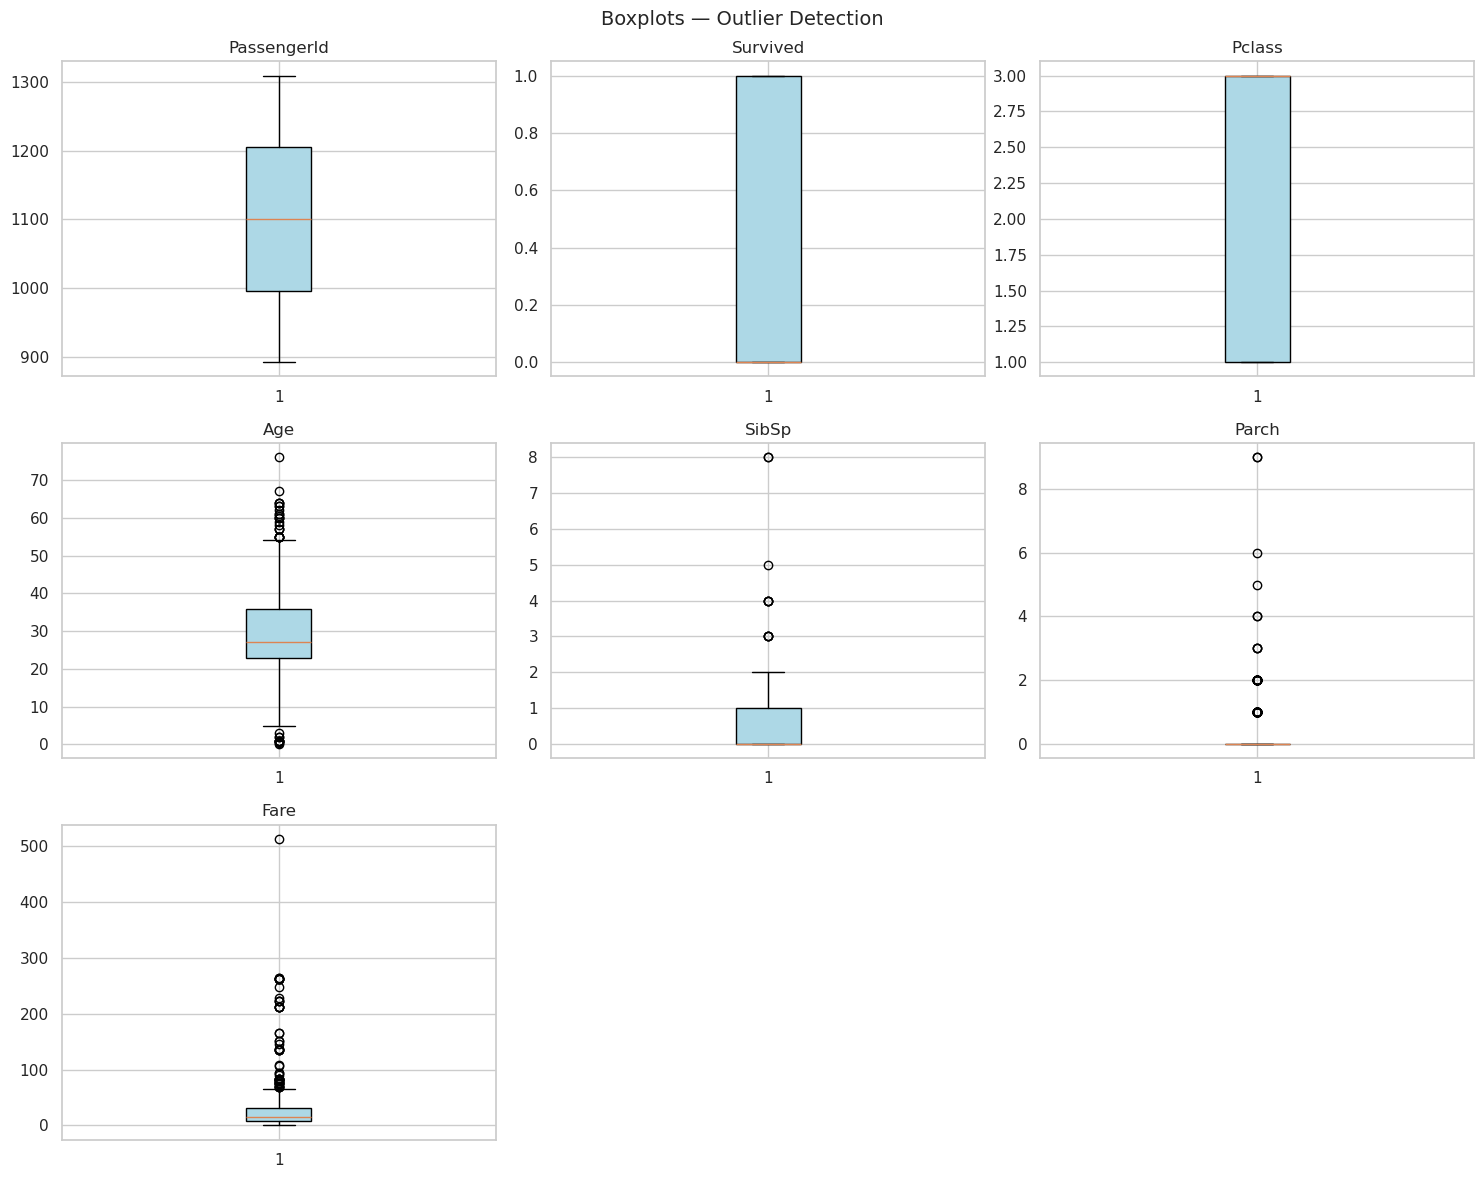

In [13]:
# Boxplots for outlier detection
if num_cols:
    n = len(num_cols)
    cols_per_row = 3
    rows = (n + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, rows * 4))
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(num_cols):
        axes[i].boxplot(df[col].dropna(), patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Boxplots — Outlier Detection', fontsize=14)
    plt.tight_layout()
    plt.show()

In [14]:
# IQR-based outlier count per column
print('Outlier counts per numeric column (IQR method):')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f'  {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

Outlier counts per numeric column (IQR method):
  PassengerId: 0 outliers (0.0%)
  Survived: 0 outliers (0.0%)
  Pclass: 0 outliers (0.0%)
  Age: 36 outliers (8.6%)
  SibSp: 11 outliers (2.6%)
  Parch: 94 outliers (22.5%)
  Fare: 55 outliers (13.2%)


## Step 7 — Bivariate Analysis & Correlation

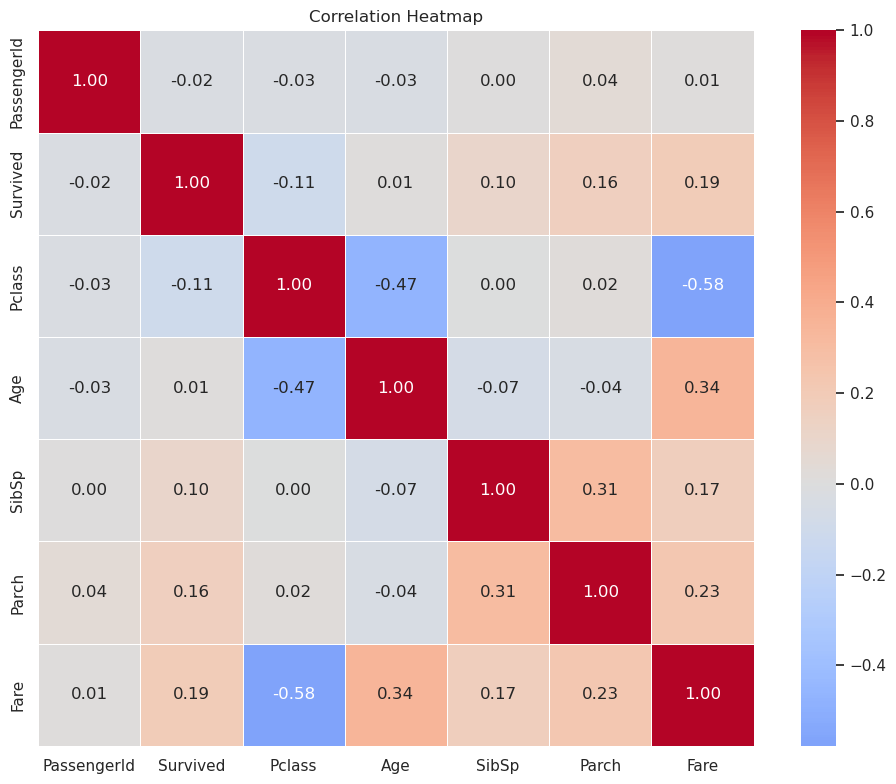

In [15]:
# Correlation heatmap
if len(num_cols) >= 2:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, square=True)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()
else:
    print('Need at least 2 numeric columns for correlation.')

In [16]:
# Top correlated pairs
if len(num_cols) >= 2:
    corr_pairs = corr.abs().unstack().sort_values(ascending=False)
    corr_pairs = corr_pairs[corr_pairs < 1].drop_duplicates()
    print('Top 10 most correlated column pairs:')
    print(corr_pairs.head(10).round(3))

Top 10 most correlated column pairs:
Fare      Pclass      0.577
Pclass    Age         0.468
Fare      Age         0.342
Parch     SibSp       0.307
Fare      Parch       0.230
Survived  Fare        0.192
Fare      SibSp       0.172
Survived  Parch       0.159
Pclass    Survived    0.109
SibSp     Survived    0.100
dtype: float64


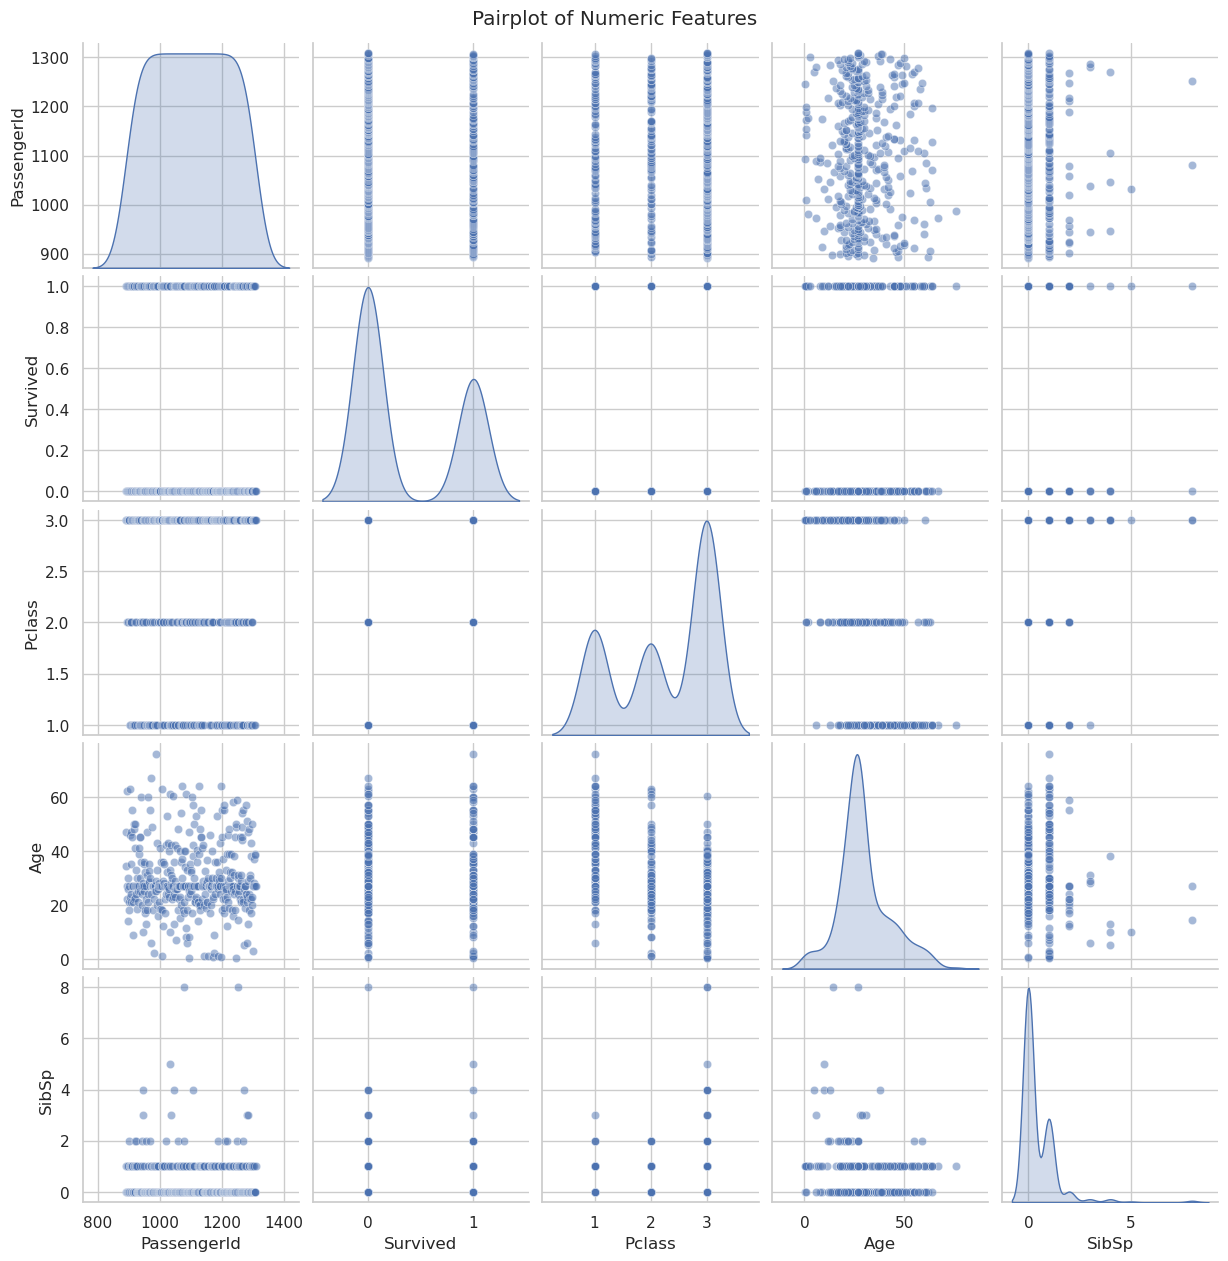

In [17]:
# Pairplot (for up to 5 numeric columns to keep it clean)
pairplot_cols = num_cols[:5]
if len(pairplot_cols) >= 2:
    sns.pairplot(df[pairplot_cols], diag_kind='kde', plot_kws={'alpha': 0.5})
    plt.suptitle('Pairplot of Numeric Features', y=1.01)
    plt.show()

## Step 8 — Insights Summary

In [18]:
print('=' * 50)
print('           EDA INSIGHTS SUMMARY')
print('=' * 50)

print(f'\n📦 Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   Numeric columns  : {len(num_cols)} → {num_cols}')
print(f'   Categorical cols : {len(cat_cols)} → {cat_cols}')

print(f'\n🧹 Data Quality:')
print(f'   Duplicates removed : {dups}')
remaining_missing = df.isnull().sum().sum()
print(f'   Missing values     : {remaining_missing} (after cleaning)')

print(f'\n📊 Numeric Statistics:')
for col in num_cols:
    print(f'   {col}: mean={df[col].mean():.2f}, std={df[col].std():.2f}, min={df[col].min():.2f}, max={df[col].max():.2f}')

print(f'\n🏷️  Categorical Summary:')
for col in cat_cols:
    print(f'   {col}: {df[col].nunique()} unique values, most common = "{df[col].mode()[0]}" ({df[col].value_counts().iloc[0]} times)')

if len(num_cols) >= 2:
    top_pair = corr_pairs.idxmax()
    top_val = corr_pairs.max()
    print(f'\n🔗 Strongest Correlation: {top_pair[0]} ↔ {top_pair[1]} (r = {top_val:.3f})')

print(f'\n⚠️  Outlier Alert:')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    out_count = len(df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)])
    if out_count > 0:
        print(f'   {col}: {out_count} outliers detected')

print('\n' + '=' * 50)
print('✅ EDA Complete. Dataset is ready for modeling.')
print('=' * 50)

           EDA INSIGHTS SUMMARY

📦 Dataset: 418 rows × 12 columns
   Numeric columns  : 7 → ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
   Categorical cols : 5 → ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

🧹 Data Quality:
   Duplicates removed : 0
   Missing values     : 0 (after cleaning)

📊 Numeric Statistics:
   PassengerId: mean=1100.50, std=120.81, min=892.00, max=1309.00
   Survived: mean=0.36, std=0.48, min=0.00, max=1.00
   Pclass: mean=2.27, std=0.84, min=1.00, max=3.00
   Age: mean=29.60, std=12.70, min=0.17, max=76.00
   SibSp: mean=0.45, std=0.90, min=0.00, max=8.00
   Parch: mean=0.39, std=0.98, min=0.00, max=9.00
   Fare: mean=35.58, std=55.85, min=0.00, max=512.33

🏷️  Categorical Summary:
   Name: 418 unique values, most common = "Abbott, Master. Eugene Joseph" (1 times)
   Sex: 2 unique values, most common = "male" (266 times)
   Ticket: 363 unique values, most common = "PC 17608" (5 times)
   Cabin: 76 unique values, most common = "B57 B

In [19]:
df.to_csv('cleaned_dataset.csv', index=False)
print('Cleaned dataset saved as cleaned_dataset.csv')

Cleaned dataset saved as cleaned_dataset.csv
